# Temporal ARSS — tgbl-enron Dataset
**Honours Project Phase II | IIIT Kottayam**

---

## What this notebook does

This notebook implements **Temporal ARSS** — a direct extension of Base ARSS that incorporates **time-decay into the reweighted similarity `w_ik`**, evaluated on **tgbl-enron** (Enron employee email network, homogeneous person→person).

### The single change vs Base ARSS

Base ARSS ranks neighbors by structural similarity alone:
```
w_ik = 2 * π_ik / (1 + η_ik)          ← Eq. 2-4, pure topology
```
Lower `w_ik` = more structurally similar = sampled first.

Temporal ARSS multiplies by an exponential recency penalty:
```
w_ik_temporal = w_ik_base * exp(+λ * Δt / T_SCALE)    ← Phase II extension
```
where `Δt = t_query - t_last_interaction(i, k)` and `λ > 0` is a fixed decay rate swept as a hyperparameter over `[1.0, 10.0]`.

**Effect:** A neighbor structurally close but last contacted long ago gets a higher `w_ik_temporal` (lower priority) than a slightly less similar neighbor contacted recently.

### What is identical to Base ARSS
- Same `w_ik` formula (Eq. 2-4) on the static training graph
- Same breadth-then-depth sampling (Eq. 5) — just using `w_ik_temporal`
- Same anonymous subgraph builder (5 structural roles)
- Same `SubgraphGNN` (GraphSAGE)
- Same `LinkPredictor` (Hadamard + common neighbor sum → MLP)
- Same training loop, evaluation, splits
- **No new model parameters** — λ is a hyperparameter, not a learned weight

### Why tgbl-enron?

tgbl-enron is homogeneous (person→person) so two employees can share mutual contacts as common neighbours. On Wikipedia JODIE (bipartite), the common-neighbour term in `z_ij` was always zero. Here it fires, giving the full ARSS representation a fair test. tgbl-uci was too sparse to converge well; tgbl-enron is denser per node.

### Pipeline overview
```
tgbl-enron (~10K timestamped employee→employee emails)
         │
         ▼
Chronological 70/15/15 split
         │
         ▼
Build STATIC graph from train edges
Precompute w_ik (Eq. 2-4)
Build t_last[i][k] lookup
         │
         ▼
For each batch of (u, v) at t_query:
   Δt = t_query - t_last[u][k]
   w_ik_temporal = w_ik_base * exp(+λ * Δt / T_SCALE)
   Sort ascending → take top-K → anonymous subgraph → GNN → MLP
         │
         ▼
Sweep λ ∈ {1.0, 10.0} — evaluate AUC/AP — compare vs Base ARSS
```


---
## Cell 1 — Imports and Device Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import copy

from torch_geometric.data import TemporalData, Data, Batch
from torch_geometric.nn import SAGEConv
from sklearn.metrics import roc_auc_score, average_precision_score
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM   : 6.4 GB


---
## Cell 2 — Load and Split the tgbl-enron Dataset

Same split logic as Base ARSS. No edge features to normalise.
Two additional temporal structures built here that Base ARSS does not need:
- **`t_last[i][k]`** — most recent training timestamp for each directed edge i→k
- **`T_SCALE`** — full training time span, normalises Δt to [0, 1] for train edges


In [2]:
from tgb.linkproppred.dataset import LinkPropPredDataset
from collections import defaultdict
import math, time as _time

# Load tgbl-enron
dataset   = LinkPropPredDataset(name='tgbl-enron', root='./data', preprocess=True)
full_data = dataset.full_data

src_all = full_data['sources'].astype(np.int64)
dst_all = full_data['destinations'].astype(np.int64)
t_all   = full_data['timestamps'].astype(np.float64)

NUM_NODES = int(max(src_all.max(), dst_all.max())) + 1
print(f'Nodes      : {NUM_NODES:,}')
print(f'Edges      : {len(src_all):,}')
print(f'Time range : [{t_all.min():.0f}, {t_all.max():.0f}]')

# Chronological 70/15/15 split
n      = len(src_all)
val_t  = t_all[int(n * 0.70)]
test_t = t_all[int(n * 0.85)]

train_mask = t_all <  val_t
val_mask   = (t_all >= val_t) & (t_all < test_t)
test_mask  = t_all >= test_t

train_src = src_all[train_mask];  train_dst = dst_all[train_mask];  train_t    = t_all[train_mask]
val_src   = src_all[val_mask];    val_dst   = dst_all[val_mask];    val_t_arr  = t_all[val_mask]
test_src  = src_all[test_mask];   test_dst  = dst_all[test_mask];   test_t_arr = t_all[test_mask]

print(f'Train      : {len(train_src):,}')
print(f'Val        : {len(val_src):,}')
print(f'Test       : {len(test_src):,}')

# T_SCALE: full training time span so delta_t/T_SCALE is in [0,1] for all train edges
T_MIN       = float(train_t.min())
T_MAX_TRAIN = float(train_t.max())
T_SCALE     = max(T_MAX_TRAIN - T_MIN, 1.0)
print(f'T_SCALE    : {T_SCALE:.1f}s  (full training time span)')

# Build static adjacency + w_ik (identical to Base ARSS)
adj    = defaultdict(set)
for u, v in zip(train_src.tolist(), train_dst.tolist()):
    adj[u].add(v)
    adj[v].add(u)

degree   = {node: len(nb_set) for node, nb_set in adj.items()}
d_max    = max(degree.values()) if degree else 1

def psi(x):
    return math.log(1.0 + x)

psi_dmax = psi(d_max)

def compute_w_ik(i, k):
    # Eq. 2-4: lower = more structurally similar
    d_i = degree.get(i, 0)
    d_k = degree.get(k, 0)
    pi_ik  = (psi(d_i) + psi(d_k)) / (2.0 * psi_dmax)
    common = adj.get(i, set()) & adj.get(k, set())
    if common:
        prod   = math.prod(psi(degree.get(u, 1)) / psi_dmax for u in common)
        eta_ik = 1.0 - prod
    else:
        eta_ik = 0.0
    return (2.0 * pi_ik) / (1.0 + eta_ik)

print('Precomputing w_ik...')
t0      = _time.time()
w_cache = {}
for node, neighbours in adj.items():
    for nb_node in neighbours:
        if (node, nb_node) not in w_cache:
            w = compute_w_ik(node, nb_node)
            w_cache[(node, nb_node)] = w
            w_cache[(nb_node, node)] = w
print(f'Done: {len(w_cache):,} pairs in {_time.time()-t0:.1f}s')
print('(Homogeneous: common neighbours between employees will be non-zero)')

# Build t_last[i][k]: most recent training timestamp per directed edge
print('Building t_last lookup...')
t_last = defaultdict(dict)
for u, v, t in zip(train_src.tolist(), train_dst.tolist(), train_t.tolist()):
    t_last[u][v] = max(t_last[u].get(v, -1), t)
    t_last[v][u] = max(t_last[v].get(u, -1), t)
print(f'Done: {sum(len(v) for v in t_last.values()):,} node-pair timestamps')


raw file found, skipping download
Dataset directory is  c:\Users\hp\Documents\GitHub\temporal-arss(honours project)\venv\Lib\site-packages\tgb/./data\tgbl_enron
loading processed file
Nodes      : 370
Edges      : 125,235
Time range : [0, 113740399]
Train      : 87,664
Val        : 18,774
Test       : 18,797
T_SCALE    : 83842852.0s  (full training time span)
Precomputing w_ik...
Done: 3,880 pairs in 0.0s
(Homogeneous: common neighbours between employees will be non-zero)
Building t_last lookup...
Done: 3,880 node-pair timestamps


---
## Cell 3 — Temporal Neighbor Sampler

The key function is `sample_subgraph_nodes_temporal`, a direct extension of
Base ARSS's `sample_subgraph_nodes`:

**Base ARSS:** rank neighbors by `w_ik` (static topology only)

**Temporal ARSS:** rank neighbors by `w_ik * exp(+λ * Δt / T_SCALE)`

where `Δt = t_query - t_last[i][k]`. The positive exponent means older edges
get a larger penalty (higher score), pushing them down the priority list.
If i and k have never interacted in training, penalty = ∞, so the neighbor
is deprioritised to the bottom of the ranking.

`λ` is a **fixed hyperparameter** swept over `[1.0, 10.0]` — it cannot be
learned via backprop because `sorted()` is outside PyTorch autograd.


In [3]:
def temporal_score(v_i, k, t_query, lam):
    """
    Temporal reweighting of w_ik (Equation 2-4 + time decay).
    w_ik_temporal = w_ik * exp(+λ * Δt / T_SCALE)
    Higher score = deprioritised (same ascending sort convention as base ARSS).
    Recent neighbors get smaller penalty → lower score → sampled first.
    Older neighbors get larger penalty  → higher score → sampled last.
    """
    w_base  = w_cache.get((v_i, k), compute_w_ik(v_i, k))
    t_last_ = t_last[v_i].get(k, None)
    if t_last_ is not None:
        dt      = max(t_query - t_last_, 0.0)
        penalty = math.exp(lam * dt / T_SCALE)   # +exponent: old = bigger score
    else:
        penalty = float('inf')                    # never interacted = lowest priority
    return w_base * penalty


def sample_subgraph_nodes_temporal(v_i, K, t_query, lam, max_hops=2):
    """
    Breadth-then-depth sampling (Equation 5) with temporal reweighting.
    Identical structure to base ARSS — only the scoring key changes.
    """
    selected     = []
    selected_set = set()
    visited      = {v_i}
    frontier     = adj.get(v_i, set()).copy()

    for _ in range(1, max_hops + 1):
        candidates = frontier - selected_set - {v_i}
        if not candidates:
            break

        remaining = K - len(selected)
        if remaining <= 0:
            break

        ranked = sorted(candidates,
                        key=lambda k: temporal_score(v_i, k, t_query, lam))

        if len(candidates) <= remaining:
            batch = ranked
        else:
            batch = ranked[:remaining]

        selected.extend(batch)
        selected_set.update(batch)
        visited.update(batch)

        if len(selected) >= K:
            break

        frontier = set()
        for nd in selected_set:
            frontier |= adj.get(nd, set())
        frontier -= visited

    return selected[:K]

---
## Cell 4 — The Temporal ARSS Model

**Identical to Base ARSS** in every component — same GNN, same link predictor,
same subgraph structure, same parameter count. No new parameters.

The only difference is outside the model: `build_batch_subgraphs_temporal`
calls `sample_subgraph_nodes_temporal` with the current `LAMBDA` and `t_query`,
so subgraph composition reflects recency at query time.


---
## Cell 4 — The Temporal ARSS Model

**Identical to Base ARSS** in every component — same GNN, same link predictor,
same subgraph structure, same parameter count. No new parameters.

The only difference is outside the model: `build_batch_subgraphs_temporal`
calls `sample_subgraph_nodes_temporal` with the current `LAMBDA` and `t_query`,
so subgraph composition reflects recency at query time.


In [4]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.data import Data, Batch

NUM_ROLES = 5

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  Anonymous Subgraph Builder (identical to Base ARSS)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def build_anonymous_subgraph(u, v, u_neighbors, v_neighbors):
    u_set  = set(u_neighbors)
    v_set  = set(v_neighbors)
    common = u_set & v_set
    all_nodes = [u, v] + list(u_set | v_set)
    n2l = {n: i for i, n in enumerate(all_nodes)}
    N   = len(all_nodes)

    roles    = torch.zeros(N, dtype=torch.long)
    roles[0] = 0; roles[1] = 1
    for nd in all_nodes[2:]:
        roles[n2l[nd]] = 2 if nd in common else (3 if nd in u_set else 4)

    x = F.one_hot(roles, num_classes=NUM_ROLES).float()

    esrc, edst = [], []
    for nb in u_neighbors:
        a, b = n2l[u], n2l[nb]; esrc += [a, b]; edst += [b, a]
    for nb in v_neighbors:
        a, b = n2l[v], n2l[nb]; esrc += [a, b]; edst += [b, a]

    if esrc:
        edge_index = torch.tensor([esrc, edst], dtype=torch.long)
    else:
        edge_index = torch.tensor([[0, 1], [1, 0]], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, common_mask=(roles == 2))


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  GNN Encoder (identical to Base ARSS)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

class SubgraphGNN(nn.Module):
    def __init__(self, in_ch=NUM_ROLES, hidden=128, out=64, layers=2, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        dims = [in_ch] + [hidden] * (layers - 1) + [out]
        self.convs = nn.ModuleList([SAGEConv(dims[i], dims[i+1]) for i in range(layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(dims[i+1]) for i in range(layers)])

    def forward(self, x, edge_index):
        for conv, norm in zip(self.convs, self.norms):
            x = conv(x, edge_index)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return x


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  Link Predictor (identical to Base ARSS, Eq. 8-9)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

class LinkPredictor(nn.Module):
    def __init__(self, emb_dim=64, hidden=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, 1)
        )

    def forward(self, h_i, h_j, h_common):
        hadamard = h_i * h_j                            # Eq. 8
        z_ij     = torch.cat([hadamard, h_common], dim=-1)
        return self.mlp(z_ij).squeeze(-1)               # Eq. 9


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  Temporal ARSS Model
#  λ is a fixed hyperparameter — no new parameters vs Base ARSS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

class TemporalARSSModel(nn.Module):
    def __init__(self, hidden=128, emb_dim=64, dropout=0.3):
        super().__init__()
        self.emb_dim   = emb_dim
        self.gnn       = SubgraphGNN(NUM_ROLES, hidden, emb_dim, 2, dropout)
        self.predictor = LinkPredictor(emb_dim, hidden)
        # λ is a hyperparameter set outside the model — not a parameter here.

    def forward(self, subgraphs):
        """subgraphs: list of Data objects. Returns logits [B]."""
        B      = len(subgraphs)
        device = next(self.parameters()).device

        batch    = Batch.from_data_list(subgraphs).to(device)
        all_embs = self.gnn(batch.x, batch.edge_index)

        starts = batch.ptr[:-1]
        h_i    = all_embs[starts]
        h_j    = all_embs[starts + 1]

        h_common = torch.zeros(B, self.emb_dim, device=device)
        for idx, sg in enumerate(subgraphs):
            cm = sg.common_mask
            if cm.any():
                start         = batch.ptr[idx].item()
                sg_embs       = all_embs[start: start + sg.num_nodes]
                h_common[idx] = sg_embs[cm.to(device)].sum(dim=0)   # Eq. 8: sum

        return self.predictor(h_i, h_j, h_common)


model = TemporalARSSModel(hidden=128, emb_dim=64, dropout=0.3).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'Parameters : {total:,}  (identical to Base ARSS)')
print(model)


Parameters : 43,073  (identical to Base ARSS)
TemporalARSSModel(
  (gnn): SubgraphGNN(
    (convs): ModuleList(
      (0): SAGEConv(5, 128, aggr=mean)
      (1): SAGEConv(128, 64, aggr=mean)
    )
    (norms): ModuleList(
      (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (predictor): LinkPredictor(
    (mlp): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): ReLU()
      (5): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)


---
## Cell 5 — Training Configuration

Same hyperparameters as Base ARSS (K=10, batch=512, epochs=15, LR=3e-4).

`build_batch_subgraphs_temporal` passes `t_query` and the current fixed `lambda` to the sampler so subgraph composition reflects recency at query time.

lambda is swept over `[1.0, 10.0]` — each value trains a fresh model from scratch and the best validation AUC selects the winner.

Because subgraph sampling is non-differentiable (`sorted()` is outside PyTorch autograd), lambda is not a learnable parameter and receives no gradient. GNN and MLP parameters are trained as usual with Adam + BCE loss.

No N_USERS offset needed: tgbl-enron is homogeneous, all node IDs in [0, NUM_NODES).


In [5]:
import os, time
import numpy as np

K          = 10
BATCH_SIZE = 512
EPOCHS     = 15
LR         = 3e-4
VALIDATE_EVERY = 1
rng = np.random.default_rng(SEED)

from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)


def get_batches_temporal(src_arr, dst_arr, t_arr, batch_size):
    n = len(src_arr)
    for s in range(0, n, batch_size):
        e = min(s + batch_size, n)
        yield src_arr[s:e], dst_arr[s:e], t_arr[s:e]


def negative_sample(src, n_nodes):
    # Random negative destination, uniform over all nodes (no offset for homogeneous graph)
    return rng.integers(0, n_nodes, size=len(src))


def bce_loss(pos_logits, neg_logits):
    logits = torch.cat([pos_logits, neg_logits])
    labels = torch.cat([torch.ones_like(pos_logits), torch.zeros_like(neg_logits)])
    return F.binary_cross_entropy_with_logits(logits, labels)


def build_batch_subgraphs_temporal(src_batch, dst_batch, t_batch, K, lam):
    """
    Build anonymous subgraphs using temporal reweighting.
    lam: current λ value (float, detached from graph for sampling).
    """
    subgraphs = []
    for u, v, t_q in zip(src_batch.tolist(), dst_batch.tolist(), t_batch.tolist()):
        u_nb = sample_subgraph_nodes_temporal(u, K, t_q, lam)
        v_nb = sample_subgraph_nodes_temporal(v, K, t_q, lam)
        subgraphs.append(build_anonymous_subgraph(u, v, u_nb, v_nb))
    return subgraphs


print(f'Config: K={K}, batch={BATCH_SIZE}, epochs={EPOCHS}, lr={LR}')
print(f'Batches per epoch: {len(train_src) // BATCH_SIZE + 1}')
print(f'T_SCALE: {T_SCALE:.1f}s')


Config: K=10, batch=512, epochs=15, lr=0.0003
Batches per epoch: 172
T_SCALE: 83842852.0s


---
## Cell 6 — Evaluation Function

Same as Base ARSS except we pass `t_arr` (timestamps) through the batch
so the temporal sampler knows `t_query` for each edge.
λ is passed as an argument — the same value used during training.


In [6]:
@torch.no_grad()
def evaluate(model, src_arr, dst_arr, t_arr, K, n_nodes, lam):
    model.eval()
    all_scores, all_labels = [], []

    for src_b, dst_b, t_b in get_batches_temporal(src_arr, dst_arr, t_arr, BATCH_SIZE):
        neg_dst = negative_sample(src_b, n_nodes)

        pos_sgs = build_batch_subgraphs_temporal(src_b, dst_b,  t_b, K, lam)
        neg_sgs = build_batch_subgraphs_temporal(src_b, neg_dst, t_b, K, lam)

        pos_logits = model(pos_sgs)
        neg_logits = model(neg_sgs)

        scores = torch.cat([pos_logits, neg_logits]).sigmoid().cpu().numpy()
        labels = np.array([1] * len(pos_logits) + [0] * len(neg_logits))
        all_scores.append(scores)
        all_labels.append(labels)

    from sklearn.metrics import roc_auc_score, average_precision_score
    all_scores = np.concatenate(all_scores)
    all_labels = np.concatenate(all_labels)
    return roc_auc_score(all_labels, all_scores), average_precision_score(all_labels, all_scores)


print('evaluate() ready ✓')


evaluate() ready ✓


---
## Cell 7 — Training Loop

Identical structure to Base ARSS. The only differences:
1. Batches include timestamps `t_b` passed to the temporal sampler
2. Each λ trial runs independently with a fresh model

**What to watch:**
- λ increasing → model learning that recency matters strongly
- λ decreasing → model learning that structural similarity alone is sufficient
- Val AUC vs Base ARSS → quantifies the value of temporal information


In [7]:
import os, time
os.makedirs('./checkpoints', exist_ok=True)

LAMBDA_CANDIDATES = [1.0, 10.0]
EPOCHS         = 15
VALIDATE_EVERY = 1
sweep_results  = {}   # lam → (best_val_auc, best_val_ap, best_epoch)

for LAMBDA in LAMBDA_CANDIDATES:
    print(f'\n{"="*55}')
    print(f'  λ = {LAMBDA}')
    print(f'{"="*55}')

    model     = TemporalARSSModel(hidden=128, emb_dim=64, dropout=0.3).to(DEVICE)
    optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

    overall_best_auc = 0.0          # ← add this BEFORE the loop
    best_train_losses = []          # ← and these
    best_val_aucs_plot = []
    best_val_epochs_plot = []
    best_lam_label = None
    best_val_auc, best_val_ap, best_epoch = 0.0, 0.0, 0
    train_losses_l, val_aucs_l, val_aps_l, val_epochs_l = [], [], [], []

    for epoch in range(1, EPOCHS + 1):
        t_epoch = time.time()
        model.train()
        epoch_loss, n_batches = 0.0, 0

        for src_b, dst_b, t_b in get_batches_temporal(train_src, train_dst, train_t, BATCH_SIZE):
            neg_dst = negative_sample(src_b, NUM_NODES)

            pos_sgs = build_batch_subgraphs_temporal(src_b, dst_b,  t_b, K, LAMBDA)
            neg_sgs = build_batch_subgraphs_temporal(src_b, neg_dst, t_b, K, LAMBDA)

            pos_logits = model(pos_sgs)
            neg_logits = model(neg_sgs)

            loss = bce_loss(pos_logits, neg_logits)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()
            n_batches  += 1

        scheduler.step()
        avg_loss = epoch_loss / n_batches
        train_losses_l.append(avg_loss)
        t_train = time.time() - t_epoch

        val_auc, val_ap = evaluate(
            model, val_src, val_dst, val_t_arr, K, NUM_NODES, LAMBDA
        )
        val_aucs_l.append(val_auc)
        val_aps_l.append(val_ap)
        val_epochs_l.append(epoch)

        tag = ''
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_val_ap  = val_ap
            best_epoch   = epoch
            torch.save(model.state_dict(),
                        f'./checkpoints/temporal_arss_lam{LAMBDA}.pt')
            tag = '  [best]'

        t_total = time.time() - t_epoch
        print(f'  Epoch {epoch:02d} | Loss {avg_loss:.4f} | '
                f'Val AUC {val_auc:.4f} | Val AP {val_ap:.4f} | '
                f'Train {t_train:.0f}s | Total {t_total:.0f}s{tag}')
        
        if best_val_auc > overall_best_auc:
            overall_best_auc      = best_val_auc
            best_train_losses     = train_losses_l.copy()
            best_val_aucs_plot    = val_aucs_l.copy()
            best_val_aps_plot     = val_aps_l.copy()
            best_val_epochs_plot  = val_epochs_l.copy()
            best_lam_label        = LAMBDA


    sweep_results[LAMBDA] = (best_val_auc, best_val_ap, best_epoch)
    print(f'  → Best: AUC={best_val_auc:.4f}  AP={best_val_ap:.4f}  @ epoch {best_epoch}')

# ── Select best λ ─────────────────────────────────────────────────────────────
print(f'\n{"="*55}')
print('  λ Sweep Summary')
print(f'{"="*55}')
print(f'  {"λ":>6}  {"Val AUC":>8}  {"Val AP":>8}  {"Epoch":>6}')
for lam, (auc, ap, ep) in sweep_results.items():
    print(f'  {lam:>6}  {auc:>8.4f}  {ap:>8.4f}  {ep:>6}')

BEST_LAMBDA = max(sweep_results, key=lambda l: sweep_results[l][0])
print(f'\n  Best λ = {BEST_LAMBDA}  '
      f'(Val AUC={sweep_results[BEST_LAMBDA][0]:.4f})')



  λ = 1.0
  Epoch 01 | Loss 0.4946 | Val AUC 0.7482 | Val AP 0.7665 | Train 90s | Total 110s  [best]
  Epoch 02 | Loss 0.4609 | Val AUC 0.7459 | Val AP 0.7686 | Train 98s | Total 115s
  Epoch 03 | Loss 0.4555 | Val AUC 0.7465 | Val AP 0.7648 | Train 93s | Total 111s
  Epoch 04 | Loss 0.4551 | Val AUC 0.7461 | Val AP 0.7627 | Train 92s | Total 110s
  Epoch 05 | Loss 0.4563 | Val AUC 0.7238 | Val AP 0.7474 | Train 92s | Total 111s
  Epoch 06 | Loss 0.4539 | Val AUC 0.7233 | Val AP 0.7473 | Train 95s | Total 115s
  Epoch 07 | Loss 0.4565 | Val AUC 0.7237 | Val AP 0.7469 | Train 85s | Total 105s
  Epoch 08 | Loss 0.4563 | Val AUC 0.7251 | Val AP 0.7478 | Train 101s | Total 121s
  Epoch 09 | Loss 0.4591 | Val AUC 0.7230 | Val AP 0.7460 | Train 101s | Total 121s
  Epoch 10 | Loss 0.4586 | Val AUC 0.7238 | Val AP 0.7456 | Train 97s | Total 117s
  Epoch 11 | Loss 0.4579 | Val AUC 0.7249 | Val AP 0.7485 | Train 96s | Total 115s
  Epoch 12 | Loss 0.4578 | Val AUC 0.7246 | Val AP 0.7476 | Train 

---
## Cell 8 — Training Curves

Plots training loss and validation AUC/AP for the best-performing λ.
The slower initial rise in validation metrics compared to Base ARSS reflects
the stronger resampling pressure — the model takes longer to settle into the
new neighbour distribution before it can learn effectively from it.


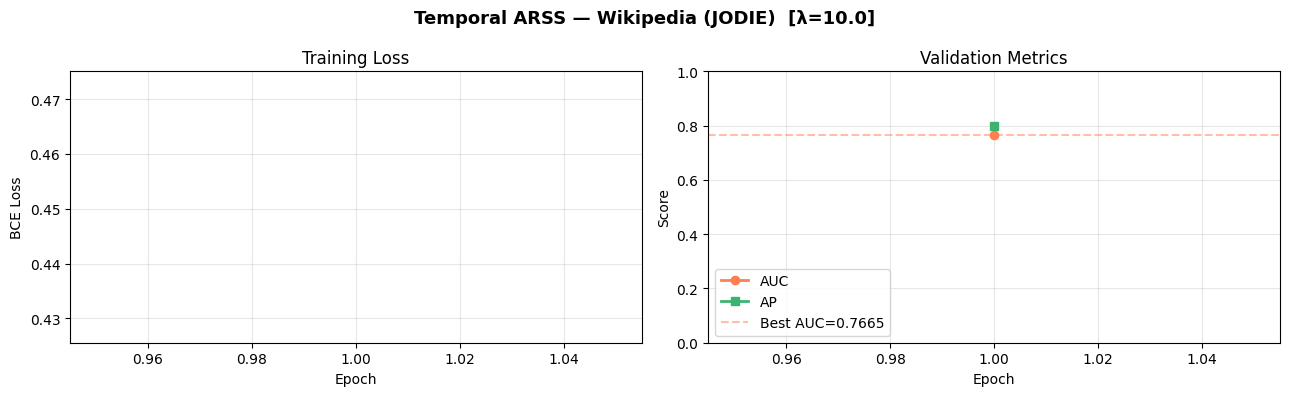

Best validation AUC: 0.7665  (λ=10.0)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(best_train_losses) + 1)

axes[0].plot(ep, best_train_losses, color='steelblue', linewidth=2)
axes[0].set(title='Training Loss', xlabel='Epoch', ylabel='BCE Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(best_val_epochs_plot, best_val_aucs_plot, 'o-', label='AUC',
             color='coral', linewidth=2)
axes[1].plot(best_val_epochs_plot, best_val_aps_plot, 's-', label='AP',
             color='mediumseagreen', linewidth=2)
axes[1].axhline(y=overall_best_auc, color='coral', linestyle='--', alpha=0.5,
                label=f'Best AUC={overall_best_auc:.4f}')
axes[1].set(title='Validation Metrics', xlabel='Epoch', ylabel='Score', ylim=(0, 1))
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Temporal ARSS — Wikipedia (JODIE)  [λ={best_lam_label}]',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('temporal_arss_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best validation AUC: {overall_best_auc:.4f}  (λ={best_lam_label})')

---
## Cell 9 — Final Test Evaluation and Comparison

Load the best checkpoint and evaluate on the test set.
Print a side-by-side comparison with base ARSS for your report.

In [9]:
model = TemporalARSSModel(hidden=128, emb_dim=64, dropout=0.3).to(DEVICE)
model.load_state_dict(torch.load(
    f'./checkpoints/temporal_arss_lam{BEST_LAMBDA}.pt', map_location=DEVICE
))

test_auc, test_ap = evaluate(
    model, test_src, test_dst, test_t_arr, K, NUM_NODES, BEST_LAMBDA
)

print('=' * 52)
print('  Temporal ARSS — Final Test Results')
print(f'  tgbl-enron  |  lambda = {BEST_LAMBDA}')
print('  w_ik_temporal = w_ik * exp(+λ·Δt/T_SCALE)')
print('=' * 52)
print(f'  AUC : {test_auc:.4f}')
print(f'  AP  : {test_ap:.4f}')
print('=' * 52)
print('\nPhase II complete. Compare AUC/AP against Base ARSS test results.')


  Temporal ARSS — Final Test Results
  tgbl-enron  |  lambda = 10.0
  w_ik_temporal = w_ik * exp(+λ·Δt/T_SCALE)
  AUC : 0.7060
  AP  : 0.7392

Phase II complete. Compare AUC/AP against Base ARSS test results.
